# Radios dataset

## Download
We need to download it from [https://northeurope1-mediap.svc.ms/transform/zip?cs=fFNQTw](https://northeurope1-mediap.svc.ms/transform/zip?cs=fFNQTw), as including it in version control would be to expensive.

In [3]:
import os

# Define the expected directories
expected_dirs = [
    'test/NORMAL', 'test/PNEUMONIA',
    'train/NORMAL', 'train/PNEUMONIA',
    'val/NORMAL', 'val/PNEUMONIA'
]

# Check if the dataset structure is already present
all_dirs_exist = all(os.path.isdir(dir) for dir in expected_dirs)

if all_dirs_exist:
    print("✅ Dataset is already in place with the correct structure.")
else:
    print("❌ Dataset structure incomplete. Download it from https://northeurope1-mediap.svc.ms/transform/zip?cs=fFNQTw")

✅ Dataset is already in place with the correct structure.


## Structure

The dataset features only images, it's already split in test, train, and evaluation parts, and file names communicate information on the type of pneumonia. Let's check out what kind of data we're working with.

In [4]:
from prettytable import PrettyTable
from glob import glob

# Initialize a table to display the results
table = PrettyTable()
table.field_names = ["Set", "NORMAL", "PNEUMONIA (Bacteria)", "PNEUMONIA (Virus)", "Total"]

# Define the sets to check
sets = ["test", "train", "val"]

# Iterate through each set and count the images
for dataset in sets:
    normal_count = len(glob(f"{dataset}/NORMAL/**/*", recursive=True))
    pneumonia_bacteria_count = len(glob(f"{dataset}/PNEUMONIA/*bacteria*", recursive=True))
    pneumonia_virus_count = len(glob(f"{dataset}/PNEUMONIA/*virus*", recursive=True))
    total_count = normal_count + pneumonia_bacteria_count + pneumonia_virus_count
    
    # Add the counts to the table
    table.add_row([dataset.capitalize(), normal_count, pneumonia_bacteria_count, pneumonia_virus_count, total_count])

# Display the table
print(table)

+-------+--------+----------------------+-------------------+-------+
|  Set  | NORMAL | PNEUMONIA (Bacteria) | PNEUMONIA (Virus) | Total |
+-------+--------+----------------------+-------------------+-------+
|  Test |  234   |         242          |        148        |  624  |
| Train |  1341  |         2530         |        1345       |  5216 |
|  Val  |   8    |          8           |         0         |   16  |
+-------+--------+----------------------+-------------------+-------+


In [5]:
from PIL import Image
import matplotlib.pyplot as plt
from glob import glob

# Helper function to display images
def display_images(image_paths, titles, cols=3):
    rows = (len(image_paths) + cols - 1) // cols
    _, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()
    
    for i, (img_path, title) in enumerate(zip(image_paths, titles)):
        img = Image.open(img_path).convert('L')  # L = luminance (grayscale)
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(title)
        axes[i].axis('off')
    
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

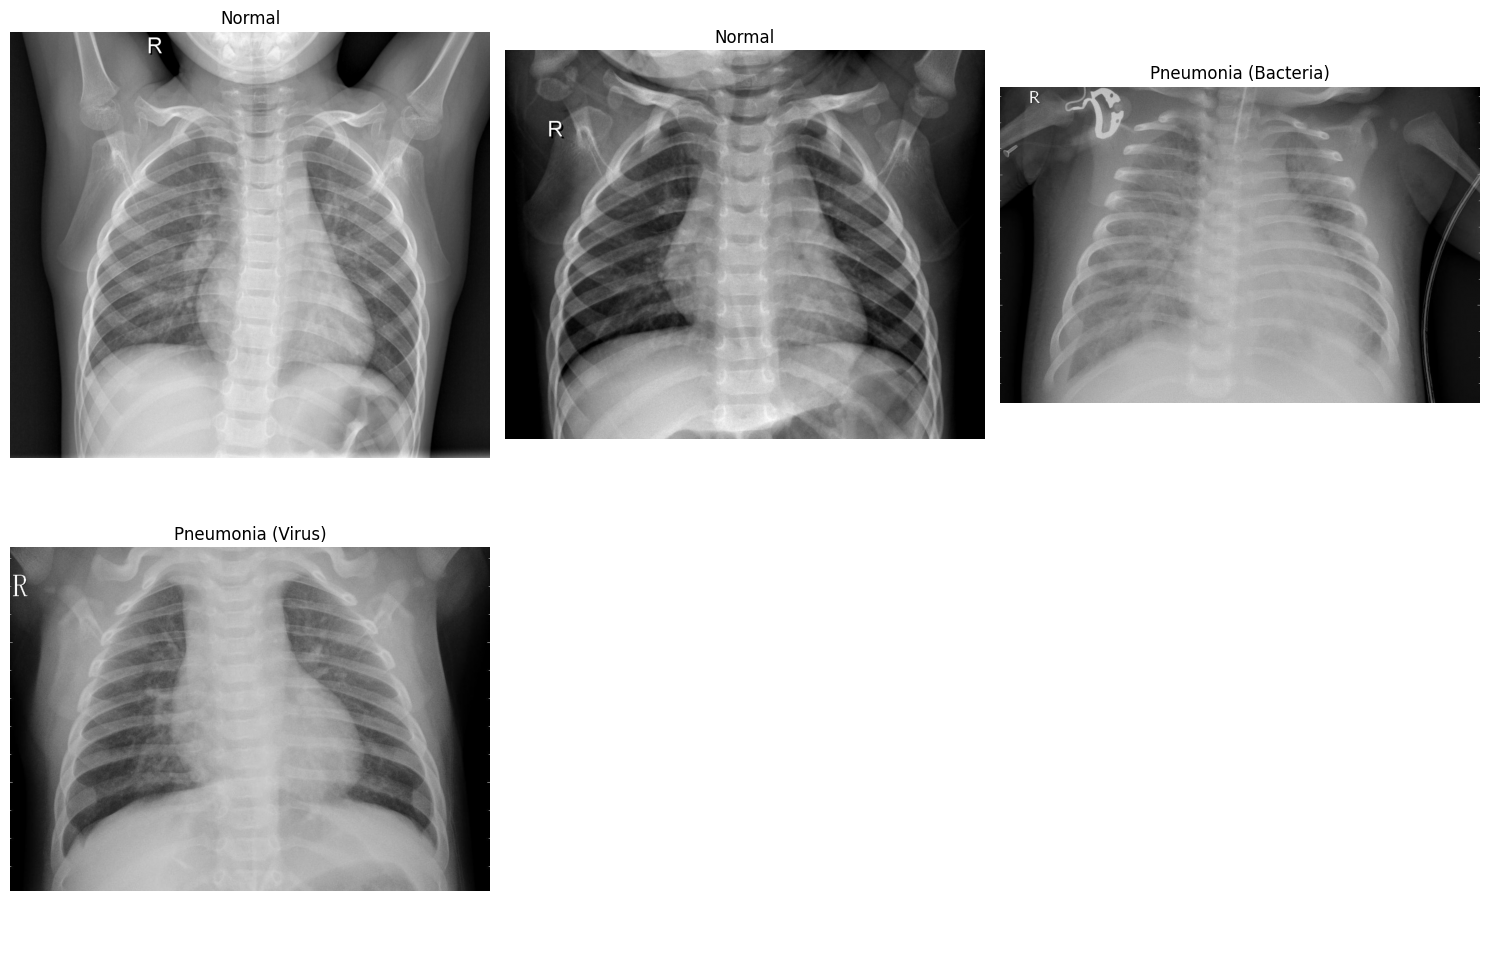

In [6]:
normal_images = glob("train/NORMAL/*")[:2]
pneumonia_bacteria_images = glob("train/PNEUMONIA/*bacteria*")[:1]
pneumonia_virus_images = glob("train/PNEUMONIA/*virus*")[:1]

# Combine the images and titles
image_paths = normal_images + pneumonia_bacteria_images + pneumonia_virus_images
titles = ["Normal"] * len(normal_images) + ["Pneumonia (Bacteria)"] * len(pneumonia_bacteria_images) + ["Pneumonia (Virus)"] * len(pneumonia_virus_images)

# Display the images
display_images(image_paths, titles)

Dimensions some to vary. Let's investigate.

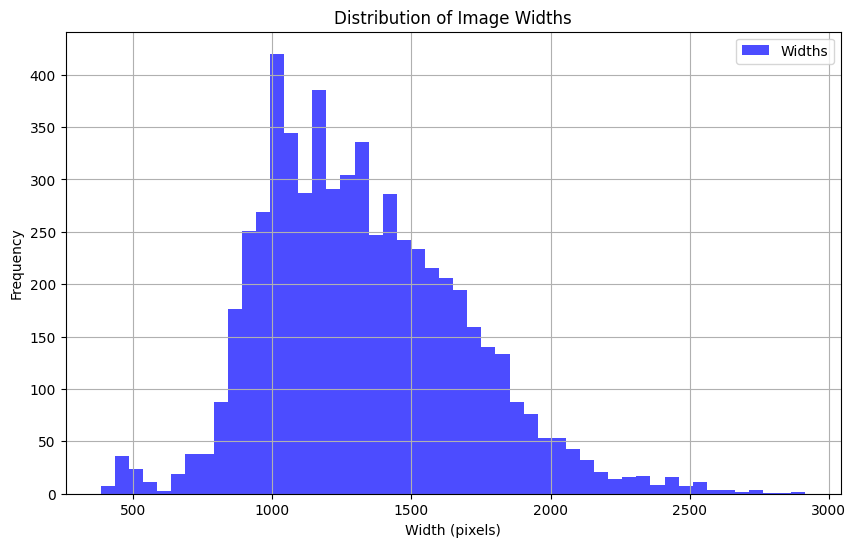

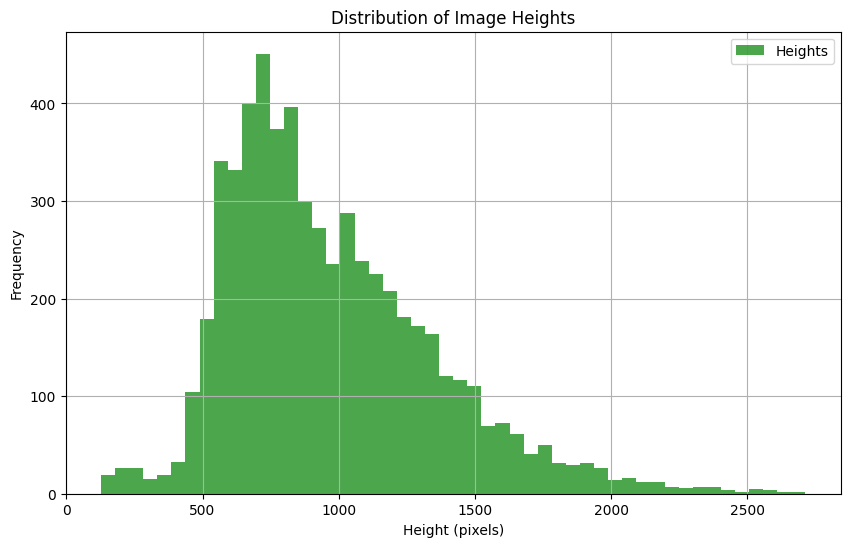

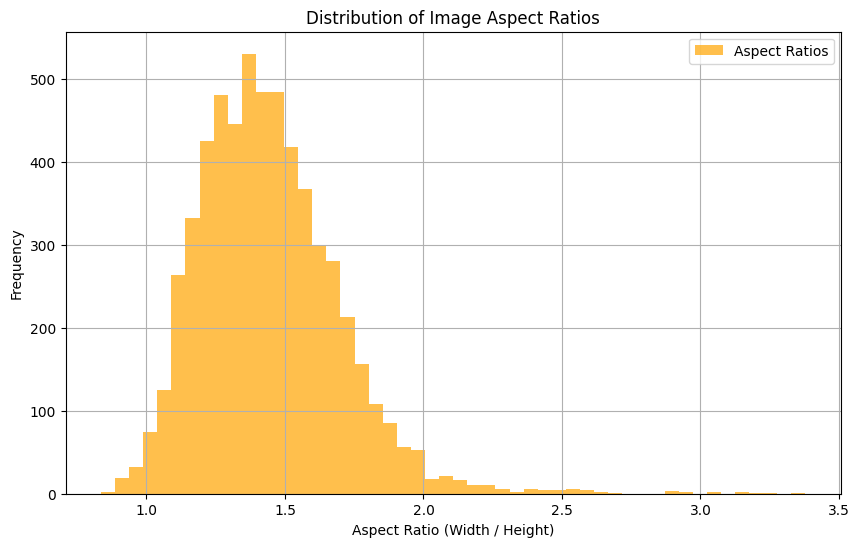

In [7]:
# Get all .jpeg and .jpg files in the folder recursively
all_image_paths = glob("**/*.jpeg", recursive=True) + glob("**/*.jpg", recursive=True)

# Analyze the whole dataset recursively
widths = []
heights = []

for img_path in all_image_paths:
    with Image.open(img_path) as img:
        widths.append(img.width)
        heights.append(img.height)

# Calculate aspect ratios
aspect_ratios = [w / h for w, h in zip(widths, heights)]

# Plot histogram for widths
plt.figure(figsize=(10, 6))
plt.hist(widths, bins=50, color='blue', alpha=0.7, label='Widths')
plt.title('Distribution of Image Widths')
plt.xlabel('Width (pixels)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

# Plot histogram for heights
plt.figure(figsize=(10, 6))
plt.hist(heights, bins=50, color='green', alpha=0.7, label='Heights')
plt.title('Distribution of Image Heights')
plt.xlabel('Height (pixels)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

# Plot histogram for aspect ratios
plt.figure(figsize=(10, 6))
plt.hist(aspect_ratios, bins=50, color='orange', alpha=0.7, label='Aspect Ratios')
plt.title('Distribution of Image Aspect Ratios')
plt.xlabel('Aspect Ratio (Width / Height)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()


We can see that image sizes vary widely, and we might need to remove some items from the dataset before moving on, as well as resizing all the images to a smaller dimension.

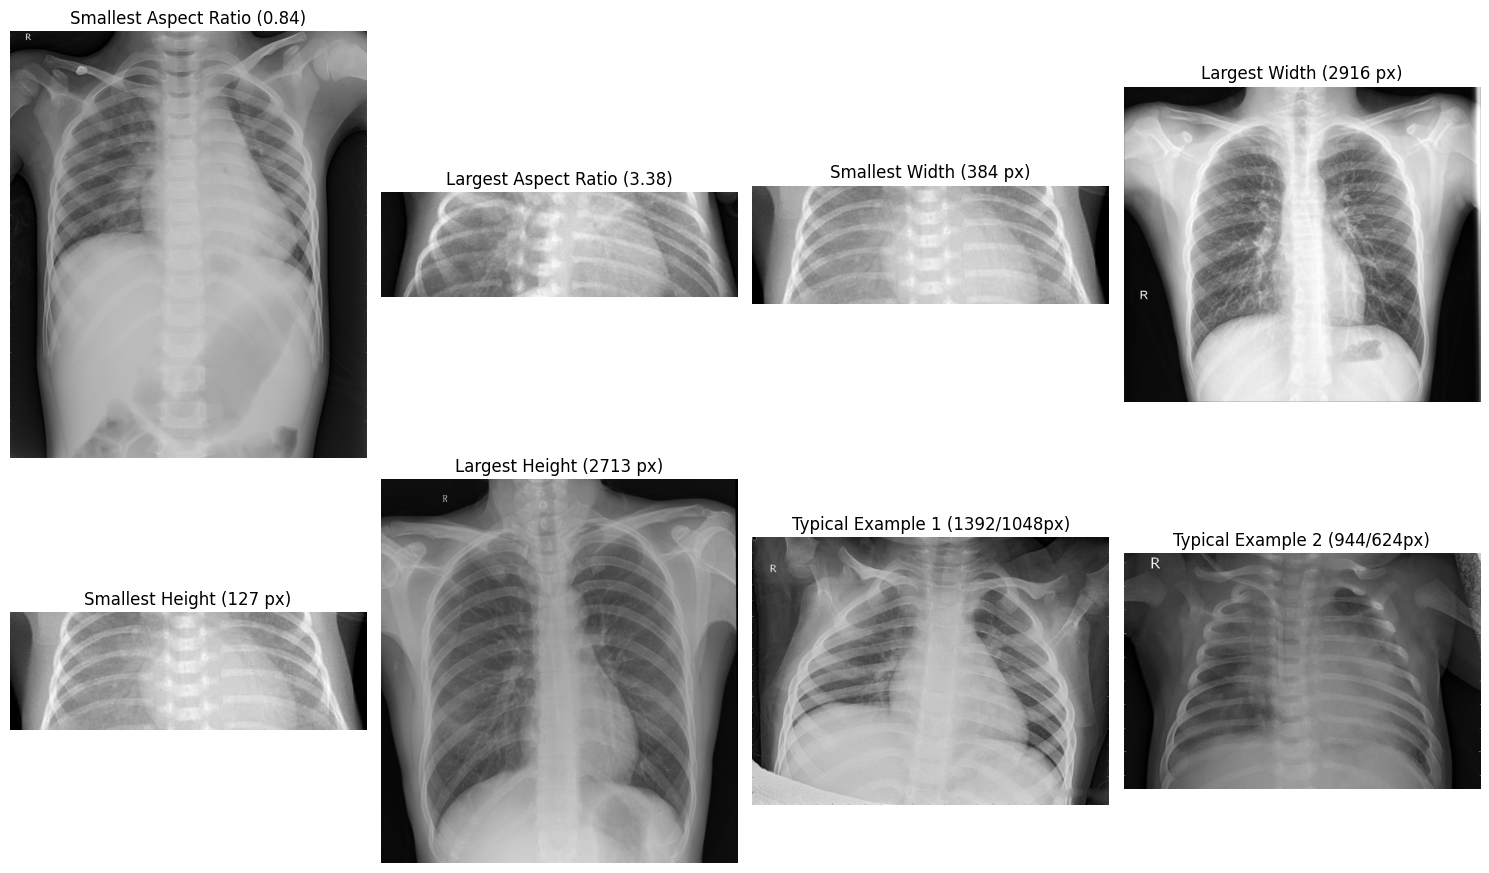

In [8]:
# Find indices of images with the smallest and largest widths and heights
max_aspect_ratio_index = aspect_ratios.index(max(aspect_ratios))
min_aspect_ratio_index = aspect_ratios.index(min(aspect_ratios))
min_width_index = widths.index(min(widths))
max_width_index = widths.index(max(widths))
min_height_index = heights.index(min(heights))
max_height_index = heights.index(max(heights))

# Select a couple of "normal" examples (middle aspect ratios)
normal_example_indices = [len(aspect_ratios) // 3, 2 * len(aspect_ratios) // 3]

# Get the corresponding image paths and titles
extreme_image_paths = [
    all_image_paths[min_aspect_ratio_index],
    all_image_paths[max_aspect_ratio_index],
    all_image_paths[min_width_index],
    all_image_paths[max_width_index],
    all_image_paths[min_height_index],
    all_image_paths[max_height_index],
    all_image_paths[normal_example_indices[0]],
    all_image_paths[normal_example_indices[1]],
]
extreme_titles = [
    f"Smallest Aspect Ratio ({min(aspect_ratios):.2f})",
    f"Largest Aspect Ratio ({max(aspect_ratios):.2f})",
    f"Smallest Width ({min(widths)} px)",
    f"Largest Width ({max(widths)} px)",
    f"Smallest Height ({min(heights)} px)",
    f"Largest Height ({max(heights)} px)",
    f"Typical Example 1 ({widths[normal_example_indices[0]]}/{heights[normal_example_indices[0]]}px)",
    f"Typical Example 2 ({widths[normal_example_indices[1]]}/{heights[normal_example_indices[1]]}px)",
]

# Display the images in an expressive layout
display_images(extreme_image_paths, extreme_titles, cols=4)

Dataset processing to resize usable images to (224, 224)

In [14]:
from PIL import Image, ImageEnhance, ImageOps
import os
from tqdm import tqdm
import numpy as np
import cv2  # Import OpenCV
import shutil

def enhance_gray_levels(source_dir, target_dir, size=(224, 224), equalize=True, contrast_factor=1.2, brightness_factor=1.0, median_blur_radius=5):
    """
    Redimensionne, ajuste la luminosité, égalise l'histogramme, améliore le contraste et applique un flou médian
    aux images en niveaux de gris dans source_dir et les enregistre dans target_dir.
    """
    if os.path.exists(target_dir):
        shutil.rmtree(target_dir)
        print(f"Le dossier '{target_dir}' a été supprimé.")

    if not os.path.exists(target_dir):
        os.makedirs(target_dir)

    for subdir, dirs, files in os.walk(source_dir):
        for file in tqdm(files, desc=f"Processing {subdir}"):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(subdir, file)
                try:
                    img = Image.open(img_path).convert('L')  # Convertir en niveaux de gris
                    img = img.resize(size, Image.LANCZOS)
                    img_np = np.array(img)  # Convertir en tableau NumPy pour OpenCV

                    # Ajustement de la luminosité
                    enhancer = ImageEnhance.Brightness(img)
                    img = enhancer.enhance(brightness_factor)
                    img_np = np.array(img) # Mise à jour de img_np après ajustement de la luminosité

                    # Égalisation de l'histogramme
                    if equalize:
                        img_np = cv2.equalizeHist(img_np)
                        img = Image.fromarray(img_np)  # Retour à l'image PIL après égalisation

                    # Amélioration du contraste
                    enhancer = ImageEnhance.Contrast(img)
                    img = enhancer.enhance(contrast_factor)
                    img_np = np.array(img) # Mise à jour de img_np après ajustement du contraste

                    # Application du flou médian
                    if median_blur_radius > 0:
                        img_np = cv2.medianBlur(img_np, median_blur_radius)
                        img = Image.fromarray(img_np)  # Retour à l'image PIL après flou médian

                    # Enregistrer l'image
                    relative_path = os.path.relpath(subdir, source_dir)
                    target_subdir = os.path.join(target_dir, relative_path)
                    if not os.path.exists(target_subdir):
                        os.makedirs(target_subdir)
                    target_path = os.path.join(target_subdir, file)
                    img.save(target_path)

                except Exception as e:
                    print(f"Error processing {img_path}: {e}")

# Définir les répertoires source et cible
source_dir = "."  # Répertoire actuel
target_dir = "standardized_dataset"  # Répertoire pour les images améliorées
equalize = True  # Activer l'égalisation de l'histogramme
contrast_factor = 1.0  # Facteur d'amélioration du contraste
brightness_factor = 1.0 # Facteur d'ajustement de la luminosité
median_blur_radius = 0  # Rayon du flou médian (0 pour désactiver)

# Améliorer les niveaux de gris des images
enhance_gray_levels(source_dir, target_dir, equalize=equalize, contrast_factor=contrast_factor, brightness_factor=brightness_factor, median_blur_radius=median_blur_radius)

print("✅ All images have been resized and enhanced to", target_dir)


Le dossier 'standardized_dataset' a été supprimé.


Processing .: 100%|██████████| 7/7 [00:00<?, ?it/s]
Processing .\logs: 0it [00:00, ?it/s]
Processing .\models: 100%|██████████| 2/2 [00:00<?, ?it/s]
Processing .\standardized_dataset: 0it [00:00, ?it/s]
Processing .\val\PNEUMONIA: 100%|██████████| 9/9 [00:00<00:00, 212.13it/s]

✅ All images have been resized and enhanced to standardized_dataset


Classification binaire avec CNN MobileNetV2 : modèle léger, efficace et pré-entraîné pour une performance optimisée.

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from PIL import Image
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
import logging

# Configuration du logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Vérification GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logging.info(f"GPU détecté: {device}")

# Répertoires
plots_dir = 'training_plots'
model_dir = 'models'
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

# Transformations (data augmentation + normalisation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=0.1, scale=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229])  # Normalisation ImageNet
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229])
])


# Chargement des datasets
train_dir = 'standardized_dataset/train'
val_dir = 'standardized_dataset/val'
test_dir = 'standardized_dataset/test'

# Custom dataset pour gérer les images corrompues
class CustomImageFolder(datasets.ImageFolder):
    def __init__(self, *args, **kwargs):
        super(CustomImageFolder, self).__init__(*args, **kwargs)

    def __getitem__(self, index):
        try:
            return super(CustomImageFolder, self).__getitem__(index)
        except Exception as e:
            logging.error(f"Error loading image at index {index}: {e}")
            # Retourner une image et un label valides (par exemple, la première image)
            return self[0]


train_dataset = CustomImageFolder(train_dir, transform=train_transforms)
val_dataset = CustomImageFolder(val_dir, transform=val_test_transforms)
test_dataset = CustomImageFolder(test_dir, transform=val_test_transforms)

# DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)  # num_workers=0
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)  # num_workers=0
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)  # num_workers=0

# Charger EfficientNet_B2 pré-entraîné avec poids ImageNet
weights = EfficientNet_B2_Weights.IMAGENET1K_V1
model = efficientnet_b2(weights=weights)

# Adapter la première couche convolutionnelle pour accepter 1 canal (grayscale)
model.features[0][0] = nn.Conv2d(
    1,
    model.features[0][0].out_channels,
    kernel_size=model.features[0][0].kernel_size,
    stride=model.features[0][0].stride,
    padding=model.features[0][0].padding,
    bias=False
)

# Geler les paramètres du feature extractor
for param in model.features.parameters():
    param.requires_grad = False

# Remplacer le classifieur (head) pour classification binaire
num_ftrs = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_ftrs, 1),
    nn.Sigmoid()
)

model = model.to(device)

# Optimizer et loss
optimizer = optim.AdamW(model.classifier.parameters(), lr=0.0007, weight_decay=0.001)  # Optimiseur AdamW
criterion = nn.BCELoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5) # Scheduler

# Fonction d'entraînement
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for i, (inputs, labels) in enumerate(dataloader):
        inputs, labels = inputs.to(device), labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        torch.cuda.empty_cache()

        running_loss += loss.item() * inputs.size(0)
        preds = (outputs > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# Fonction de validation / test
def eval_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.float().unsqueeze(1).to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            preds = (outputs > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# Entraînement avec EarlyStopping et sauvegarde du meilleur modèle
num_epochs = 50
best_val_loss = float('inf')
patience = 5
counter = 0

torch.cuda.empty_cache()  # Ajouté ici
logging.info("Starting training...")
for epoch in range(num_epochs):
    logging.info(f"Epoch {epoch+1}/{num_epochs}")
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = eval_model(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    logging.info(f"Epoch {epoch+1}/{num_epochs} - Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f} - Val loss: {val_loss:.4f}, Val acc: {val_acc:.4f}")

    # Sauvegarde du meilleur modèle
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), os.path.join(model_dir, 'best_model.pth'))
        counter = 0
        logging.info("Meilleur modèle sauvegardé.")
    else:
        counter += 1
        if counter >= patience:
            logging.info("Early stopping")
            break

# Évaluation finale sur test set
logging.info("Starting evaluation...")
test_loss, test_acc = eval_model(model, test_loader, criterion, device)
logging.info(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

# Sauvegarde du modèle final
torch.save(model.state_dict(), os.path.join(model_dir, 'final_model.pth'))
logging.info(f"✅ Model saved to {os.path.join(model_dir, 'final_model.pth')}")


2025-04-22 16:42:48,181 - INFO - GPU détecté: cuda
2025-04-22 16:42:48,395 - INFO - Starting training...
2025-04-22 16:42:48,396 - INFO - Epoch 1/50
2025-04-22 16:43:27,757 - INFO - Epoch 1/50 - Train loss: 0.5226, Train acc: 0.7467 - Val loss: 0.6723, Val acc: 0.6250
2025-04-22 16:43:27,811 - INFO - Meilleur modèle sauvegardé.
2025-04-22 16:43:27,813 - INFO - Epoch 2/50
2025-04-22 16:43:43,124 - INFO - Epoch 2/50 - Train loss: 0.4167, Train acc: 0.8121 - Val loss: 0.5558, Val acc: 0.7500
2025-04-22 16:43:43,183 - INFO - Meilleur modèle sauvegardé.
2025-04-22 16:43:43,184 - INFO - Epoch 3/50
2025-04-22 16:43:58,770 - INFO - Epoch 3/50 - Train loss: 0.3779, Train acc: 0.8276 - Val loss: 0.5600, Val acc: 0.7500
2025-04-22 16:43:58,770 - INFO - Epoch 4/50
2025-04-22 16:44:13,712 - INFO - Epoch 4/50 - Train loss: 0.3511, Train acc: 0.8539 - Val loss: 0.5422, Val acc: 0.7500
2025-04-22 16:44:13,770 - INFO - Meilleur modèle sauvegardé.
2025-04-22 16:44:13,770 - INFO - Epoch 5/50
2025-04-22 1